In [1]:
library(Seurat)
library(ggplot2)
library(patchwork)
library(dplyr)
library(scattermore)

Warning message:
“package ‘Seurat’ was built under R version 4.5.2”
Loading required package: SeuratObject

Warning message:
“package ‘SeuratObject’ was built under R version 4.5.3”
Loading required package: sp

Warning message:
“package ‘sp’ was built under R version 4.5.2”

Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘dplyr’ was built under R version 4.5.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [2]:
filter_obj <- readRDS('../Data/Visium_HD_segmentation.rds')

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


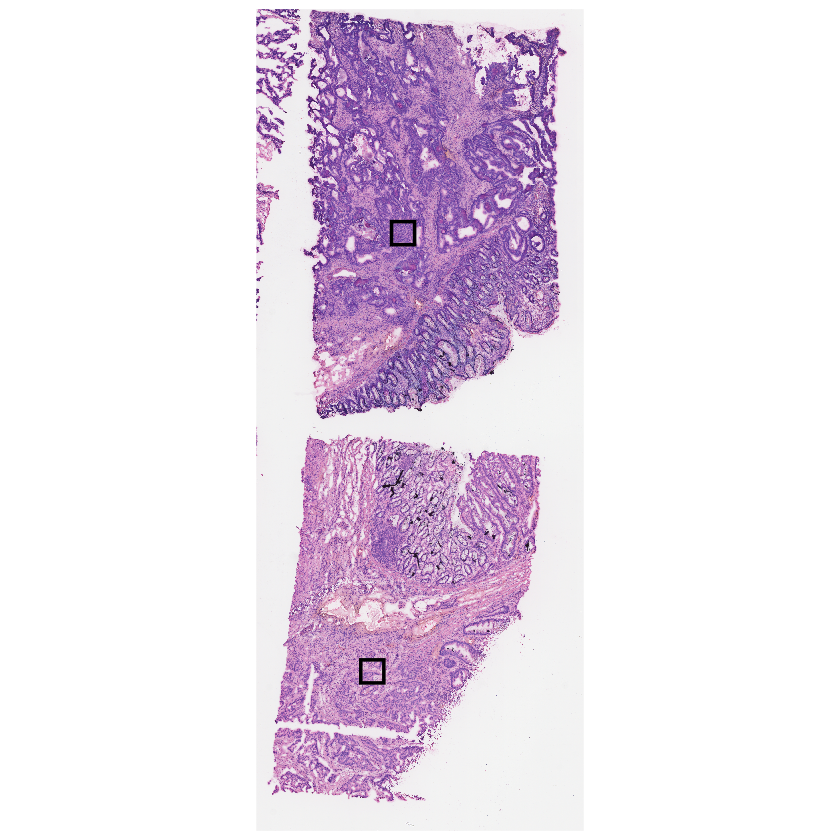

In [3]:
# Fig 7A
SpatialDimPlot(filter_obj,
            images = "slice1.polygons",
            alpha = 0,
            image.scale = "hires") +NoLegend() +      
            geom_rect(aes(xmin=2850, xmax=3000, ymin=2000, ymax=2150),fill=NA,color="black",size=1) + 
            geom_rect(aes(xmin=2650, xmax=2800, ymin=4850, ymax=5000),fill=NA,color="black",size=1)
                                   

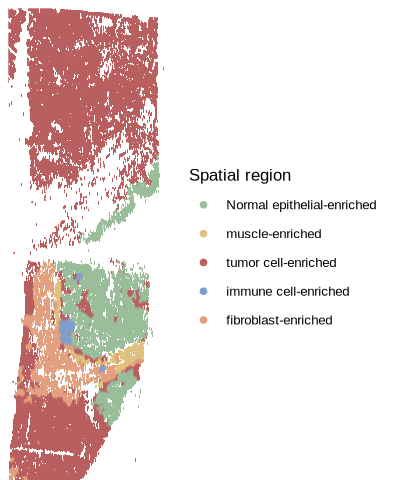

In [4]:
# Fig 7B
options(repr.plot.width = 3.5, repr.plot.height = 4) 
ColorPalette2 <- function() { 
  Colors <- c(
    '4' = "#7F9FCB",
    '5'                    = "#E2A07F",
    '2'                    = "#DFC27D",
    '3'            = "#B95F5F",
    '1'            = "#9ABD9A"
  )
  return(Colors)
}

theme_spatial_publication <- function() {
  theme_minimal(base_size = 10) +
  theme(
    axis.text = element_blank(),
    axis.title = element_blank(),
    panel.grid = element_blank(),
    plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50"),
    plot.margin = margin(t = 5, r = 5, b = -8, l = 5, unit = "pt")
  )
}

filter_obj[[]] %>% 
  ggplot(aes(x = X, y = -Y, color = niches)) +
  geom_scattermore(pointsize = 8, pixels = rep(2000, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_manual(values = ColorPalette2(), drop = FALSE,name='Spatial region',,labels=c('3'='tumor cell-enriched','5'='fibroblast-enriched','1'='Normal epithelial-enriched','4'='immune cell-enriched','2'='muscle-enriched')) +
  theme_spatial_publication()

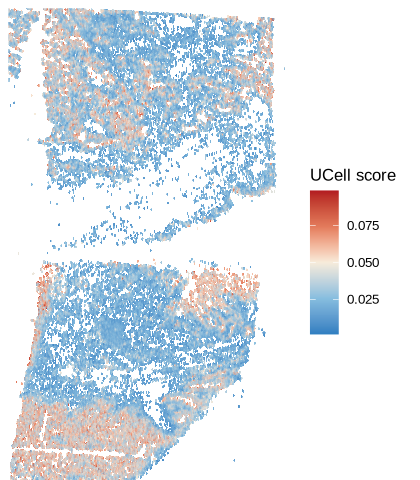

In [5]:
# Fig 7C
my_palette <- c(
  "#2F7FC1", 
  "#87BEDF", 
  "#F7ECDB", 
  "#E37B5C", 
  "#B31B21" 
)

filter_obj[[]] %>% 
  ggplot(aes(x = X, y = -Y, color = marker_sig_UCell)) +
  geom_scattermore(pointsize = 8, pixels = rep(2500, 2)) +
  coord_cartesian(expand = FALSE) +
  scale_color_gradientn(colors=my_palette)+
  theme_spatial_publication() + labs(color = "UCell score")


Warning message:
“Setting row names on a tibble is deprecated.”


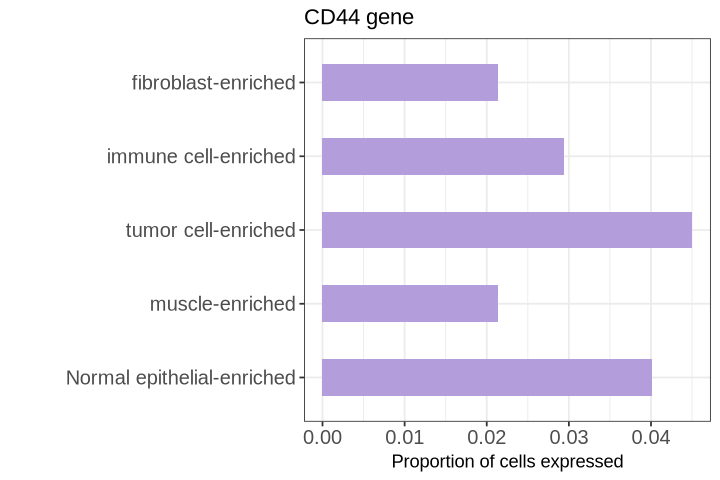

In [6]:
# Fig 7D
options(repr.plot.width = 6, repr.plot.height = 4) 
order_type <- paste('region',unique(filter_obj@meta.data[['niches']]),sep='_')
mat <- GetAssayData(filter_obj, assay = "Spatial.Polygons", layer = "data")

expr_bool <- mat['CD44', ] > 1 

df <- data.frame(
  cell = colnames(filter_obj),
  expr = as.integer(expr_bool),
  niches = filter_obj@meta.data[['niches']]
)

prop_df <- df %>%
  group_by(niches) %>%
  summarise(
    n_cells = n(),
    n_expr  = sum(expr == 1),
    prop_expr = n_expr / n_cells,
    .groups = "drop"
  ) %>%
  arrange(desc(prop_expr)) %>%
  mutate(label_n = paste0(n_expr, "/", n_cells))  
rownames(prop_df) <- paste('region',prop_df$niches,sep='_')
prop_df <- prop_df[order_type, ]

ggplot(prop_df, aes(x = niches, y = prop_expr)) +
  geom_col(fill = "#B39DDB",width=0.5) +
  scale_x_discrete(
    labels = c('3'='tumor cell-enriched','5'='fibroblast-enriched','1'='Normal epithelial-enriched','4'='immune cell-enriched','2'='muscle-enriched')
  ) +
  coord_flip() +
  ggtitle('CD44 gene') + 
  ylab(paste0("Proportion of cells expressed")) +
  xlab("") +
  theme_bw() + theme(axis.text=element_text(size=12))

Warning message:
“Setting row names on a tibble is deprecated.”


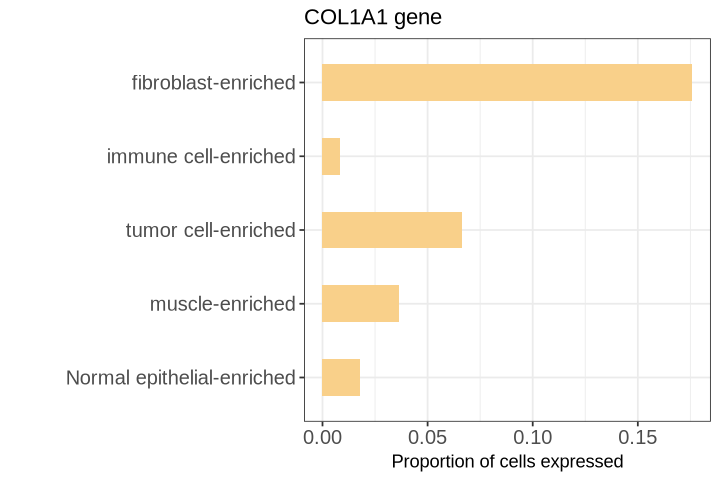

In [7]:

options(repr.plot.width = 6, repr.plot.height = 4) 
mat <- GetAssayData(filter_obj, assay = "Spatial.Polygons", layer = "data")
expr_bool <- mat['COL1A1', ] > 1 

df <- data.frame(
  cell = colnames(filter_obj),
  expr = as.integer(expr_bool),
  niches = filter_obj@meta.data[['niches']]
)

prop_df <- df %>%
  group_by(niches) %>%
  summarise(
    n_cells = n(),
    n_expr  = sum(expr == 1),
    prop_expr = n_expr / n_cells,
    .groups = "drop"
  ) %>%
  arrange(desc(prop_expr)) %>%
  mutate(label_n = paste0(n_expr, "/", n_cells))  
rownames(prop_df) <- paste('region',prop_df$niches,sep='_')
prop_df <- prop_df[order_type, ]
ggplot(prop_df, aes(x = niches, y = prop_expr)) +
  geom_col(fill = "#F9D08A",width=0.5) +
  scale_x_discrete(
    labels = c('3'='tumor cell-enriched','5'='fibroblast-enriched','1'='Normal epithelial-enriched','4'='immune cell-enriched','2'='muscle-enriched')
  ) +
  coord_flip() +
  ylab(paste0("Proportion of cells expressed")) +
  ggtitle('COL1A1 gene') + 
  xlab("") +
  theme_bw() + theme(axis.text=element_text(size=12))

Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


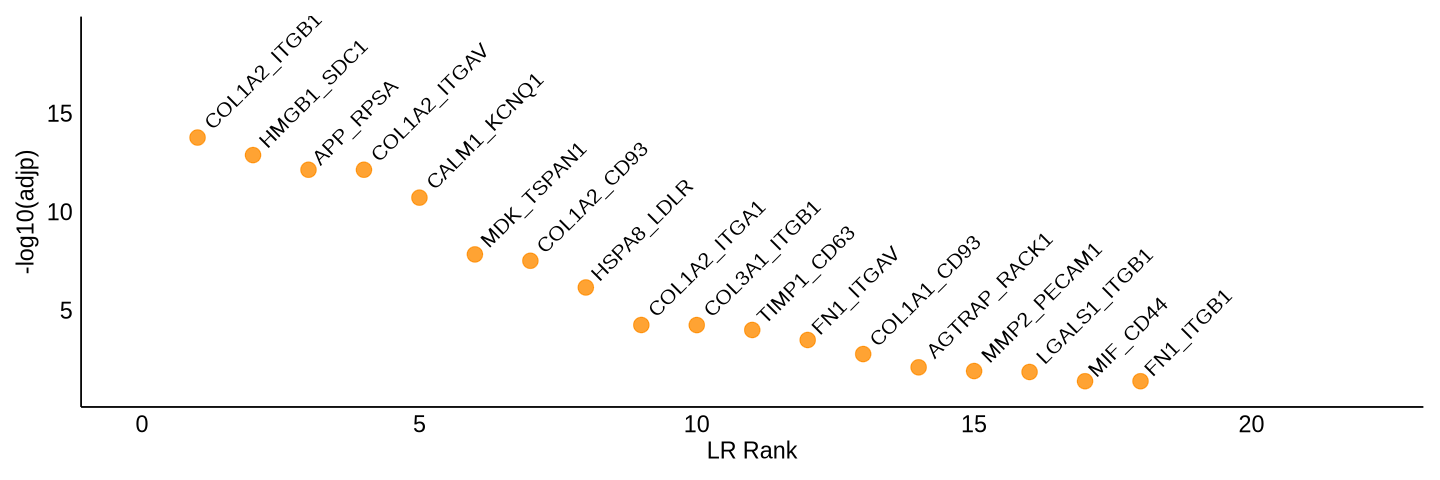

In [8]:
# Fig 7E
options(repr.plot.width = 12, repr.plot.height = 4) 
test_lr <- read.csv('../Data/validation_lr_SpaGene.csv')

data <- data.frame(
  rank = 1:18,
  n_spots_sig = -log10(test_lr$adjp),
  labels = test_lr$X
  )


ggplot(data, aes(x = rank, y = n_spots_sig)) +
  geom_point(color = "#FF8C00", size = 4, alpha = 0.8) +
  geom_text(aes(label = labels), 
            angle = 45, 
            hjust = -0.1, 
            vjust = 0.4,
            size = 4.5,
            color = "black") +
  labs(x = "LR Rank", 
       y = "-log10(adjp)") +
  scale_x_continuous(limits = c(0, 22)) +
  scale_y_continuous(limits = c(1, 19)) +
  theme_minimal() +
  theme(
    axis.line = element_line(color = "black", size = 0.5),
    axis.text = element_text(size = 14, color = "black"),
    axis.title = element_text(size = 14, color = "black"),
    panel.grid = element_blank(),
    plot.margin = margin(10, 10, 10, 10)
  )


In [9]:
plotLR2 <- function(expr, location, normalize = TRUE, 
                   topn = floor(0.2 * dim(location)[1]), knn = 8, 
                   LRpair = c("Ptn", "Ptprz1"), pt.size = 1.2, 
                   alpha.min = 0.1, max.cut = 0.95,
                   flip_y = TRUE,flip=FALSE) { 
  

  location_mat <- as.matrix(location)
  if (!is.numeric(location_mat)) {
    stop("error")
  }
  
  invalid_rows <- rowSums(is.na(location_mat) | is.nan(location_mat) | !is.finite(location_mat)) > 0
  if (any(invalid_rows)) {
    num_bad <- sum(invalid_rows)
    location_mat <- location_mat[!invalid_rows, , drop = FALSE]
    expr <- expr[, !invalid_rows, drop = FALSE]
  }
  
  if (sum(rownames(expr) %in% LRpair) != 2) { 
    stop("error")
  }
  

  countsum <- Matrix::colSums(expr)
  ncell <- dim(expr)[2]
  
  if (normalize == TRUE) {
    expr <- Matrix::t(log(Matrix::t(expr) / countsum * median(countsum) + 1))
  }
  
  ligand <- expr[LRpair[1], ]
  receptor <- expr[LRpair[2], ]
  
  if (sum(ligand > 0) > topn) {
    n1 <- order(ligand, sample(ncell, ncell), decreasing = TRUE)[1:topn]
  } else {
    n1 <- which(ligand > 0)
  }
  
  if (sum(receptor > 0) > topn) {
    n2 <- order(receptor, sample(ncell, ncell), decreasing = TRUE)[1:topn]
  } else {
    n2 <- which(receptor > 0)
  }
  
  expcol <- rep(0, ncell)
  expcol[n1] <- 1
  expcol[n2] <- 2
  expcol[intersect(n1, n2)] <- 3
  

  tmp <- data.frame(x = location_mat[, 1], y = location_mat[, 2], Exp = as.factor(expcol))
  rm(expcol)
  rm(expr)
  rm(location_mat)
  gc()
  
  discrete_cols <- c(
    "0" = "#F2F3F4",  
    "1" = "#2E86C1",  
    "2" = "#E74C3C",  
    "3" = "#F1C40F"  
  )
  
  spatial_theme <- theme_void() + 
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 11, color = "#2C3E50", margin = margin(b = 8)),
      legend.title = element_text(face = "bold", size = 9, color = "#2C3E50"),
      legend.text = element_text(size = 8, color = "#2C3E50"),
      legend.position = "right",
      plot.margin = margin(10, 10, 10, 10)
    )
  
  if(flip){
    p1 <- ggplot(tmp, aes(x = y, y = x, col = Exp)) +
      geom_point(size = pt.size, shape = 16) +
      scale_color_manual(
        values = discrete_cols,
        labels = c("Both low", "Ligand high", "Receptor High", "Both High")
      ) +
      coord_fixed(ratio = 1) +  
      ggtitle("Expression Co-localization") +
      spatial_theme +
      labs(color = "Expression\nStatus")
  }else{
    p1 <- ggplot(tmp, aes(x = x, y = y, col = Exp)) +
    geom_point(size = pt.size, shape = 16) +
    scale_color_manual(
      values = discrete_cols,
      labels = c("Both low", "Ligand high", "Receptor High", "Both High")
    ) +
    coord_fixed(ratio = 1) +  
    ggtitle("Expression Co-localization") +
    spatial_theme +
    labs(color = "Expression\nStatus")
  }
  
  if (flip_y) {
    p1 <- p1 + scale_y_reverse()
  }

  return(p1)
}

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 26.8 GiB”


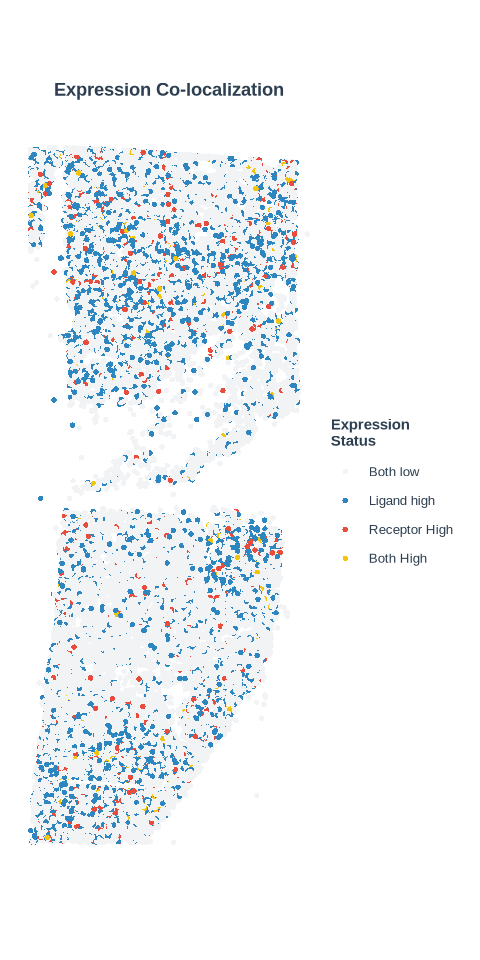

In [10]:
# Fig 7F
counts <- GetAssayData(filter_obj, assay = "Spatial.Polygons", layer = "counts")
coords <- as.matrix(GetTissueCoordinates(filter_obj)[,1:2])
options(repr.plot.width = 4, repr.plot.height =8)  
plotLR2(counts,coords,LRpair=c("MIF","CD44"))


In [11]:
sessionInfo()

R version 4.5.1 (2025-06-13)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 16.04.6 LTS

Matrix products: default
BLAS:   /home/amax/anaconda3/envs/zxc/lib/libblas.so.3.9.0 
LAPACK: /home/amax/anaconda3/envs/zxc/lib/liblapack.so.3.9.0  LAPACK version 3.9.0

locale:
 [1] LC_CTYPE=C.UTF-8           LC_NUMERIC=C              
 [3] LC_TIME=zh_CN.UTF-8        LC_COLLATE=C              
 [5] LC_MONETARY=zh_CN.UTF-8    LC_MESSAGES=C             
 [7] LC_PAPER=zh_CN.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=zh_CN.UTF-8 LC_IDENTIFICATION=C       

time zone: Asia/Shanghai
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] scattermore_1.2    dplyr_1.2.1        patchwork_1.3.2    ggplot2_4.0.3     
[5] Seurat_5.4.0       SeuratObject_5.4.0 sp_2.2-1          

loaded via a namespace (and not attached):
  [1] 